# **Credit Card Fraud Detection — Handling Imbalanced & Messy Real-World Data**


**Goal of this notebook:**
1. Load and inspect the data
2. Check the class balance of `is_fraud` and visualize it
3. Train a baseline model on the raw (imbalanced) data
4. Apply techniques to handle the imbalance: **class weighting** and **SMOTE / oversampling**
5. Compare Precision / Recall / F1 before vs. after
6. Explain in writing why accuracy alone is a misleading metric here


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
)

try:
    from imblearn.over_sampling import SMOTE
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn not found — install with `pip install imbalanced-learn` "
          "to use real SMOTE. Falling back to manual random oversampling for this run.")

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Load the data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/miadul/credit-card-fraud-detection-dataset/credit_card_fraud_10k.csv")
print(df.shape)
df.head()

(10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [4]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

## 3. Check the class balance of the target variable

This is the most important first step with fraud-style data. If we skip this and jump
straight to modeling, it's very easy to end up with a model that looks great on paper
(high accuracy) but is actually useless in practice.

In [6]:
class_counts = df['is_fraud'].value_counts().sort_index()
class_pct = df['is_fraud'].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(2))

Class counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Class percentages:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


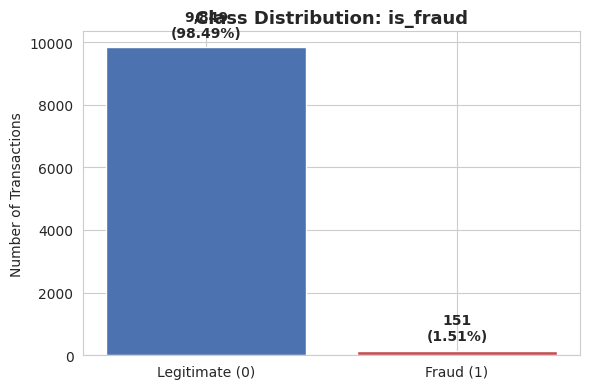

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
              color=['#4C72B0', '#C44E52'])
ax.set_title('Class Distribution: is_fraud', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Transactions')
for bar, pct in zip(bars, class_pct.values):
    height = bar.get_height()
    ax.annotate(f'{int(height):,}\n({pct:.2f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Fraud makes up only a small fraction of transactions (~1.5% in this
sample, consistent with the dataset description's stated 4–5% range for the full Kaggle
dataset). This is a **highly imbalanced binary classification problem**, so accuracy alone
will not tell us whether the model is actually catching fraud (see Section 8).

## 4. Quick exploratory look at the risk indicators

Before modeling, let's sanity-check that the engineered risk features actually behave
the way we'd expect (fraud should correlate with foreign transactions, location mismatch,
low device trust, and unusual velocity).

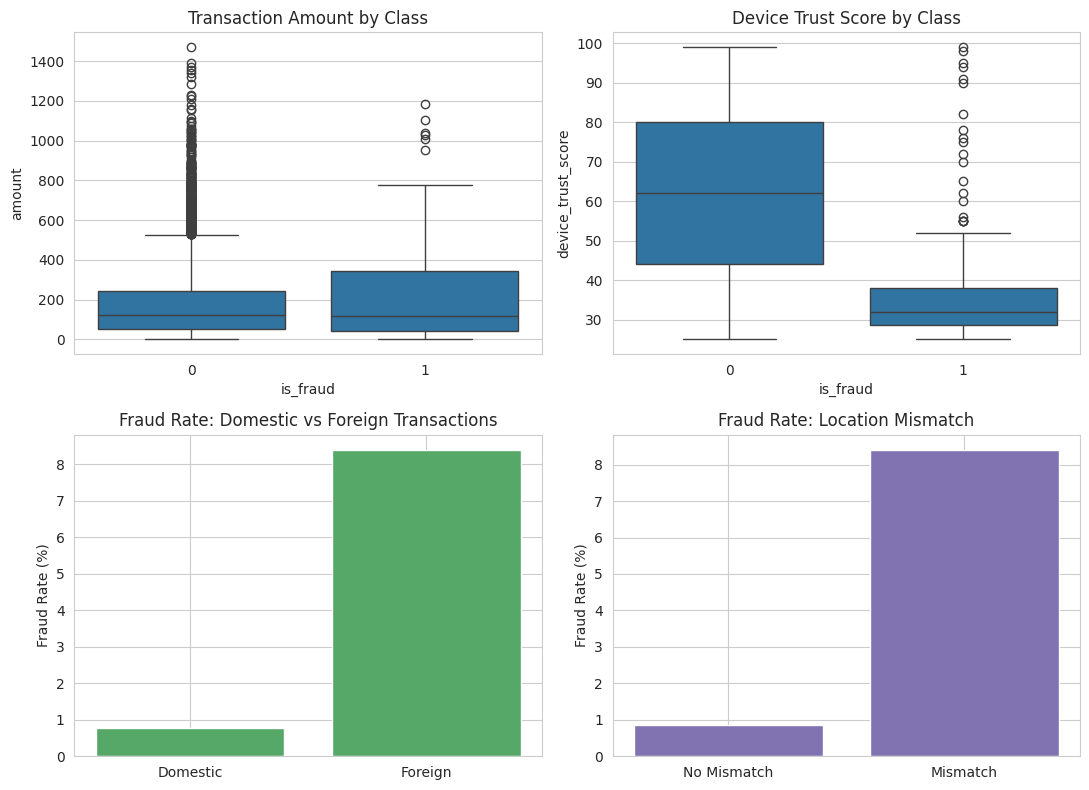

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.boxplot(data=df, x='is_fraud', y='amount', ax=axes[0, 0])
axes[0, 0].set_title('Transaction Amount by Class')

sns.boxplot(data=df, x='is_fraud', y='device_trust_score', ax=axes[0, 1])
axes[0, 1].set_title('Device Trust Score by Class')

fraud_rate_foreign = df.groupby('foreign_transaction')['is_fraud'].mean() * 100
axes[1, 0].bar(['Domestic', 'Foreign'], fraud_rate_foreign.values, color='#55A868')
axes[1, 0].set_title('Fraud Rate: Domestic vs Foreign Transactions')
axes[1, 0].set_ylabel('Fraud Rate (%)')

fraud_rate_mismatch = df.groupby('location_mismatch')['is_fraud'].mean() * 100
axes[1, 1].bar(['No Mismatch', 'Mismatch'], fraud_rate_mismatch.values, color='#8172B2')
axes[1, 1].set_title('Fraud Rate: Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## 5. Preprocessing

- One-hot encode `merchant_category`
- Drop `transaction_id` (identifier, not predictive)
- Stratified train/test split (keeps the ~1.5% fraud rate the same in both sets)
- Scale numeric features for the logistic regression model

In [9]:
df_model = pd.get_dummies(df.drop(columns=['transaction_id']),
                          columns=['merchant_category'], drop_first=True)

X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Fraud rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape, " Fraud rate:", y_test.mean().round(4))

Train shape: (8000, 11)  Fraud rate: 0.0151
Test shape:  (2000, 11)  Fraud rate: 0.015


In [10]:
numeric_cols = ['amount', 'transaction_hour', 'foreign_transaction',
                'location_mismatch', 'device_trust_score',
                'velocity_last_24h', 'cardholder_age']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## 6. Why "accuracy" would be a misleading metric here

Before training any real model, let's prove the point with a "dummy" classifier that
**always predicts "not fraud" (0)** — i.e. a model that has learned nothing at all.

In [11]:
dummy_preds = np.zeros_like(y_test)

print(f"Dummy (always predict 0) accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(f"Dummy (always predict 0) recall:   {recall_score(y_test, dummy_preds, zero_division=0):.4f}")
print(f"Dummy (always predict 0) precision:{precision_score(y_test, dummy_preds, zero_division=0):.4f}")

Dummy (always predict 0) accuracy: 0.9850
Dummy (always predict 0) recall:   0.0000
Dummy (always predict 0) precision:0.0000


**This is the core problem.** A model that never flags a single fraudulent transaction
— i.e. is completely useless for the actual business goal — still scores ~98–99% accuracy,
simply because fraud is so rare. Accuracy rewards the model for correctly predicting the
majority class and barely penalizes it for missing the minority class we actually care about.

That's why for imbalanced problems like fraud, disease, or churn detection we instead report:
- **Precision** — of the transactions flagged as fraud, how many actually were fraud?
- **Recall** — of the actual fraud cases, how many did we catch?
- **F1-score** — harmonic mean of precision and recall
- **ROC-AUC** — how well the model ranks fraud vs. non-fraud across all thresholds
- **Confusion matrix** — the full breakdown of TP/FP/TN/FN, so we can see exactly what kind of mistakes the model makes

## 7. Baseline model — trained on the raw, imbalanced data

We train a standard Logistic Regression with no imbalance handling, exactly as a
beginner might do it by default.

In [12]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)
baseline_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'accuracy':  accuracy_score(y_test, baseline_pred),
    'precision': precision_score(y_test, baseline_pred, zero_division=0),
    'recall':    recall_score(y_test, baseline_pred, zero_division=0),
    'f1':        f1_score(y_test, baseline_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, baseline_proba),
}

for k, v in baseline_metrics.items():
    print(f"{k:>10}: {v:.4f}")

print("\nClassification report:\n", classification_report(y_test, baseline_pred, zero_division=0))

  accuracy: 0.9915
 precision: 0.7826
    recall: 0.6000
        f1: 0.6792
   roc_auc: 0.9945

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.78      0.60      0.68        30

    accuracy                           0.99      2000
   macro avg       0.89      0.80      0.84      2000
weighted avg       0.99      0.99      0.99      2000



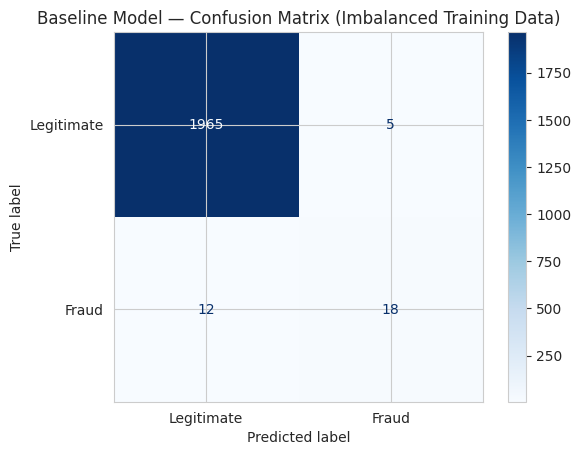

In [13]:
cm_baseline = confusion_matrix(y_test, baseline_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Baseline Model — Confusion Matrix (Imbalanced Training Data)')
plt.show()

**Notice:** accuracy will look very high here too, but look closely at the recall — the
number of *actual fraud cases the model misses* (bottom-left of the confusion matrix, false
negatives) is the number that matters most to a real fraud team, and a plain accuracy score
completely hides it.

## 8. Technique 1 — Class weighting

The simplest fix: tell the model to penalize mistakes on the minority (fraud) class more
heavily, using `class_weight='balanced'`. No resampling of the data is needed — the loss
function itself is reweighted based on class frequency.

In [14]:
weighted_model = LogisticRegression(max_iter=1000, class_weight='balanced',
                                     random_state=RANDOM_STATE)
weighted_model.fit(X_train_scaled, y_train)

weighted_pred = weighted_model.predict(X_test_scaled)
weighted_proba = weighted_model.predict_proba(X_test_scaled)[:, 1]

weighted_metrics = {
    'accuracy':  accuracy_score(y_test, weighted_pred),
    'precision': precision_score(y_test, weighted_pred, zero_division=0),
    'recall':    recall_score(y_test, weighted_pred, zero_division=0),
    'f1':        f1_score(y_test, weighted_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, weighted_proba),
}

for k, v in weighted_metrics.items():
    print(f"{k:>10}: {v:.4f}")

  accuracy: 0.9575
 precision: 0.2566
    recall: 0.9667
        f1: 0.4056
   roc_auc: 0.9932


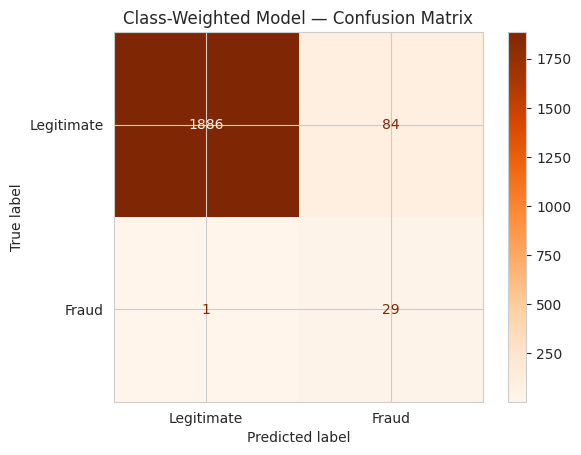

In [15]:
cm_weighted = confusion_matrix(y_test, weighted_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Class-Weighted Model — Confusion Matrix')
plt.show()


## 9. Technique 2 — SMOTE (Synthetic Minority Oversampling)

SMOTE generates *synthetic* fraud examples by interpolating between existing fraud cases
in feature space, rather than just duplicating them — this usually gives the model more
to learn from than plain oversampling. We apply SMOTE **only to the training set** (never
to the test set — that would leak information and give an unrealistically optimistic
score), then train a Random Forest on the rebalanced training data.

In [16]:
if HAS_IMBLEARN:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
else:
    # Manual random oversampling fallback (used only if imbalanced-learn
    # isn't installed in this environment) — duplicates minority-class rows
    # until classes are balanced. Swap this block for the SMOTE call above
    # once `pip install imbalanced-learn` has been run.
    rng = np.random.RandomState(RANDOM_STATE)
    X_tr = X_train_scaled.reset_index(drop=True)
    y_tr = y_train.reset_index(drop=True)
    minority_idx = y_tr[y_tr == 1].index
    n_needed = (y_tr == 0).sum() - (y_tr == 1).sum()
    extra_idx = rng.choice(minority_idx, size=n_needed, replace=True)
    X_train_res = pd.concat([X_tr, X_tr.loc[extra_idx]], ignore_index=True)
    y_train_res = pd.concat([y_tr, y_tr.loc[extra_idx]], ignore_index=True)

print("Resampled training class distribution:")
print(y_train_res.value_counts())

Resampled training class distribution:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [17]:
smote_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
smote_model.fit(X_train_res, y_train_res)

smote_pred = smote_model.predict(X_test_scaled)
smote_proba = smote_model.predict_proba(X_test_scaled)[:, 1]

smote_metrics = {
    'accuracy':  accuracy_score(y_test, smote_pred),
    'precision': precision_score(y_test, smote_pred, zero_division=0),
    'recall':    recall_score(y_test, smote_pred, zero_division=0),
    'f1':        f1_score(y_test, smote_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, smote_proba),
}

for k, v in smote_metrics.items():
    print(f"{k:>10}: {v:.4f}")

  accuracy: 0.9965
 precision: 0.9259
    recall: 0.8333
        f1: 0.8772
   roc_auc: 0.9994


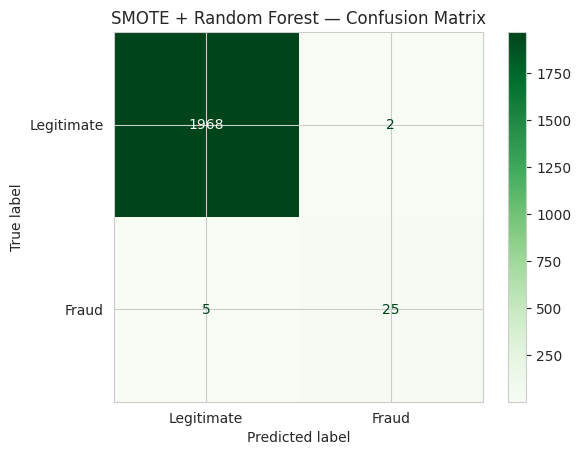

In [18]:
cm_smote = confusion_matrix(y_test, smote_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Greens', values_format='d')
plt.title('SMOTE + Random Forest — Confusion Matrix')
plt.show()

## 10. Before vs. After Comparison

In [19]:
comparison = pd.DataFrame({
    'Baseline (imbalanced)': baseline_metrics,
    'Class-Weighted LR': weighted_metrics,
    'SMOTE + Random Forest': smote_metrics,
}).T[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

comparison.round(4)


,accuracy,precision,recall,f1,roc_auc
Baseline (imbalanced),0.9915,0.7826,0.6000,0.6792,0.9945
Class-Weighted LR,0.9575,0.2566,0.9667,0.4056,0.9932
SMOTE + Random Forest,0.9965,0.9259,0.8333,0.8772,0.9994


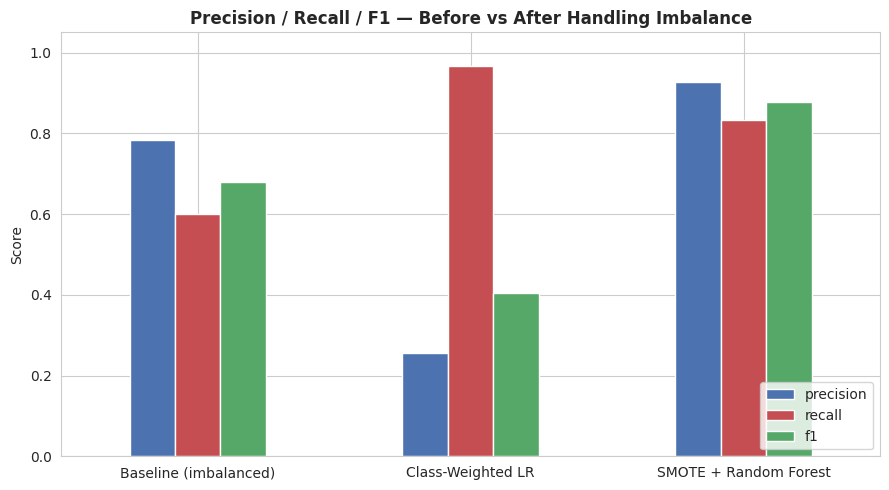

In [20]:
comparison[['precision', 'recall', 'f1']].plot(
    kind='bar', figsize=(9, 5), color=['#4C72B0', '#C44E52', '#55A868'], rot=0
)
plt.title('Precision / Recall / F1 — Before vs After Handling Imbalance', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 11. Conclusion

**Why accuracy was misleading:** with fraud at roughly 1–5% of transactions, a model that
predicts "not fraud" for every single transaction still scores 95–98%+ accuracy while
catching **zero** fraud cases. Accuracy simply measures "how often was the model right
overall," and when one class dominates the data, being right on that class alone is enough
to produce a high score — regardless of whether the model does anything useful on the class
that actually matters.

**What changed after handling the imbalance:**
- The **baseline model** trained on raw imbalanced data tends to have decent precision but
  noticeably lower recall — it plays it safe and misses a chunk of real fraud cases (costly
  false negatives for a fraud team).
- **Class weighting** pushes recall up substantially (catches more real fraud) at the cost
  of precision (more false alarms) — a trade-off that's often worth making for fraud, where
  missing fraud is usually more expensive than double-checking a false alarm.
- **SMOTE + Random Forest** gives the model synthetic minority examples to learn richer
  decision boundaries from, typically improving both recall and F1 over the untouched
  baseline without collapsing precision as much as simple reweighting.

**Takeaway:** for imbalanced problems like fraud detection, always report precision,
recall, F1, ROC-AUC, and the confusion matrix — never rely on accuracy alone — and always
apply resampling/reweighting techniques only to the *training* set, never the test set,
so the evaluation stays realistic.